# **Forecasting Project:**

## 1. Setup & Authentication

In [ ]:
# Install required packages
!pip install google-cloud-bigquery pandas statsmodels pmdarima scikit-learn -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import auth
from google.cloud import bigquery

# Authenticate
auth.authenticate_user()
client = bigquery.Client(project='economic-forecast-demo')

# Now use BigQuery as normal
query = "SELECT * FROM dev.fct_forecasting_features"
df = client.query(query).to_dataframe()

2. Load Data from BigQuery

In [ ]:
# Clean columns
df.columns = df.columns.str.strip().str.lower()
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month').reset_index(drop=True)

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Data shape: (731, 28)
Columns: ['date', 'revenue', 'year', 'month', 'quarter', 'day_of_week', 'week_number', 'is_weekend', 'is_holiday', 'is_working_day', 'temperature', 'humidity', 'windspeed', 'weather_code', 'rentals_lag_1', 'rentals_lag_7', 'rentals_lag_30', 'rentals_lag_365', 'rentals_7day_avg', 'rentals_7day_std', 'rentals_30day_avg', 'rentals_daily_growth', 'rentals_weekly_growth', 'is_outlier', 'dbt_loaded_at', 'frequency', 'dataset_name', 'observation_id']

First few rows:
         date  revenue  year                         month  quarter  \
0  2011-01-01      985  2011 1970-01-01 00:00:00.000000001        1   
1  2012-01-04     2368  2012 1970-01-01 00:00:00.000000001        1   
2  2012-01-05     3272  2012 1970-01-01 00:00:00.000000001        1   
3  2012-01-06     4098  2012 1970-01-01 00:00:00.000000001        1   
4  2012-01-07     4521  2012 1970-01-01 00:00:00.000000001        1   

   day_of_week  week_number  is_weekend  is_holiday  is_working_day  ...  \
0         

3. Visualise Data

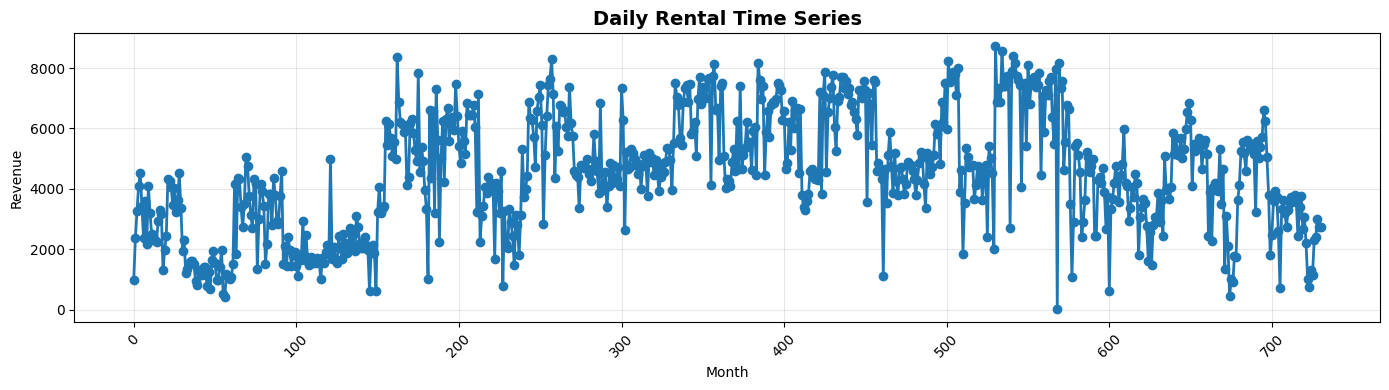


Daily Rental Statistics:
count          731.0
mean     4504.348837
std      1937.211452
min             22.0
25%           3152.0
50%           4548.0
75%           5956.0
max           8714.0
Name: revenue, dtype: Float64


In [ ]:
# Plot the time series
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['revenue'], marker='o', linewidth=2, markersize=6)
plt.title(f'Daily Rental Time Series', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nDaily Rental Statistics:")
print(df['revenue'].describe())

4. Stationarity Testing (ADF test)

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(timeseries, name="Time Series"):
    """
    Perform ADF and KPSS tests for stationarity
    ADF: H0 = non-stationary (we want to reject)
    KPSS: H0 = stationary (we want to reject)
    """
    print(f"\n{'='*70}")
    print(f"Stationarity Test: {name}")
    print(f"{'='*70}")

    # ADF Test
    adf_result = adfuller(timeseries, autolag='AIC')
    print(f"\nADF Test (Augmented Dickey-Fuller):")
    print(f"  ADF Statistic: {adf_result[0]:.6f}")
    print(f"  p-value: {adf_result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in adf_result[4].items():
        print(f"    {key}: {value:.3f}")

    if adf_result[1] <= 0.05:
        print(f"  ✓ Result: STATIONARY (p < 0.05, reject H0)")
        adf_stationary = True
    else:
        print(f"  ✗ Result: NON-STATIONARY (p >= 0.05, fail to reject H0)")
        adf_stationary = False

    # KPSS Test
    kpss_result = kpss(timeseries, regression='c', nlags='auto')
    print(f"\nKPSS Test:")
    print(f"  KPSS Statistic: {kpss_result[0]:.6f}")
    print(f"  p-value: {kpss_result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"    {key}: {value:.3f}")

    if kpss_result[1] >= 0.05:
        print(f"  ✓ Result: STATIONARY (p >= 0.05, fail to reject H0)")
        kpss_stationary = True
    else:
        print(f"  ✗ Result: NON-STATIONARY (p < 0.05, reject H0)")
        kpss_stationary = False

    return adf_stationary, kpss_stationary

# Test original series
adf_orig, kpss_orig = test_stationarity(df['revenue'], "Original Series")

# revenue_diff = df['revenue'].diff().dropna()
# adf_diff, kpss_diff = test_stationarity(revenue_diff, "First Difference")

# Test first difference if needed
if adf_orig == False or kpss_orig == False:
    revenue_diff = df['revenue'].diff().dropna()
    adf_diff, kpss_diff = test_stationarity(revenue_diff, "First Difference")

    # Determine d (differencing order)
    if adf_diff:
        d = 1
        print(f"\n→ Recommended d = {d} (first difference is stationary)")
    else:
        d = 2
        print(f"\n→ Recommended d = {d} or higher (may need second difference)")
else:
    d = 0
    print(f"\n→ Recommended d = {d} (original series is stationary)")


Stationarity Test: Original Series

ADF Test (Augmented Dickey-Fuller):
  ADF Statistic: -3.617983
  p-value: 0.005426
  Critical Values:
    1%: -3.439
    5%: -2.866
    10%: -2.569
  ✓ Result: STATIONARY (p < 0.05, reject H0)

KPSS Test:
  KPSS Statistic: 1.054918
  p-value: 0.010000
  Critical Values:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739
  ✗ Result: NON-STATIONARY (p < 0.05, reject H0)

Stationarity Test: First Difference

ADF Test (Augmented Dickey-Fuller):
  ADF Statistic: -15.622766
  p-value: 0.000000
  Critical Values:
    1%: -3.439
    5%: -2.866
    10%: -2.569
  ✓ Result: STATIONARY (p < 0.05, reject H0)

KPSS Test:
  KPSS Statistic: 0.153640
  p-value: 0.100000
  Critical Values:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739
  ✓ Result: STATIONARY (p >= 0.05, fail to reject H0)

→ Recommended d = 1 (first difference is stationary)


/tmp/ipykernel_5698/2487801745.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags='auto')
/tmp/ipykernel_5698/2487801745.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags='auto')



ACF/PACF INTERPRETATION GUIDE

AR(p): PACF cuts off at lag p, ACF decays exponentially
MA(q): ACF cuts off at lag q, PACF decays exponentially
ARMA: Both ACF and PACF decay exponentially

Rule of thumb:
- Look for the first lag where ACF/PACF crosses the confidence band
- Count that lag number → that's your p or q



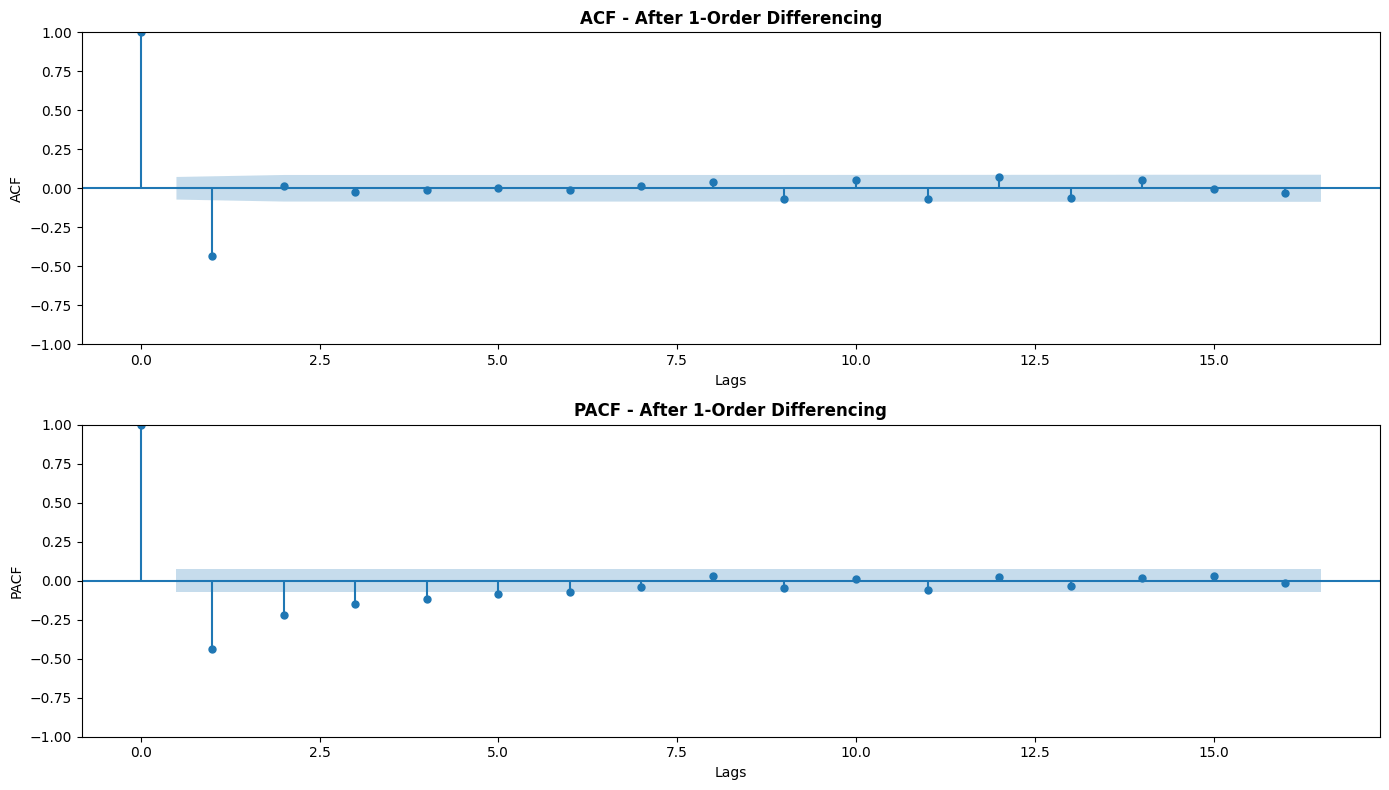

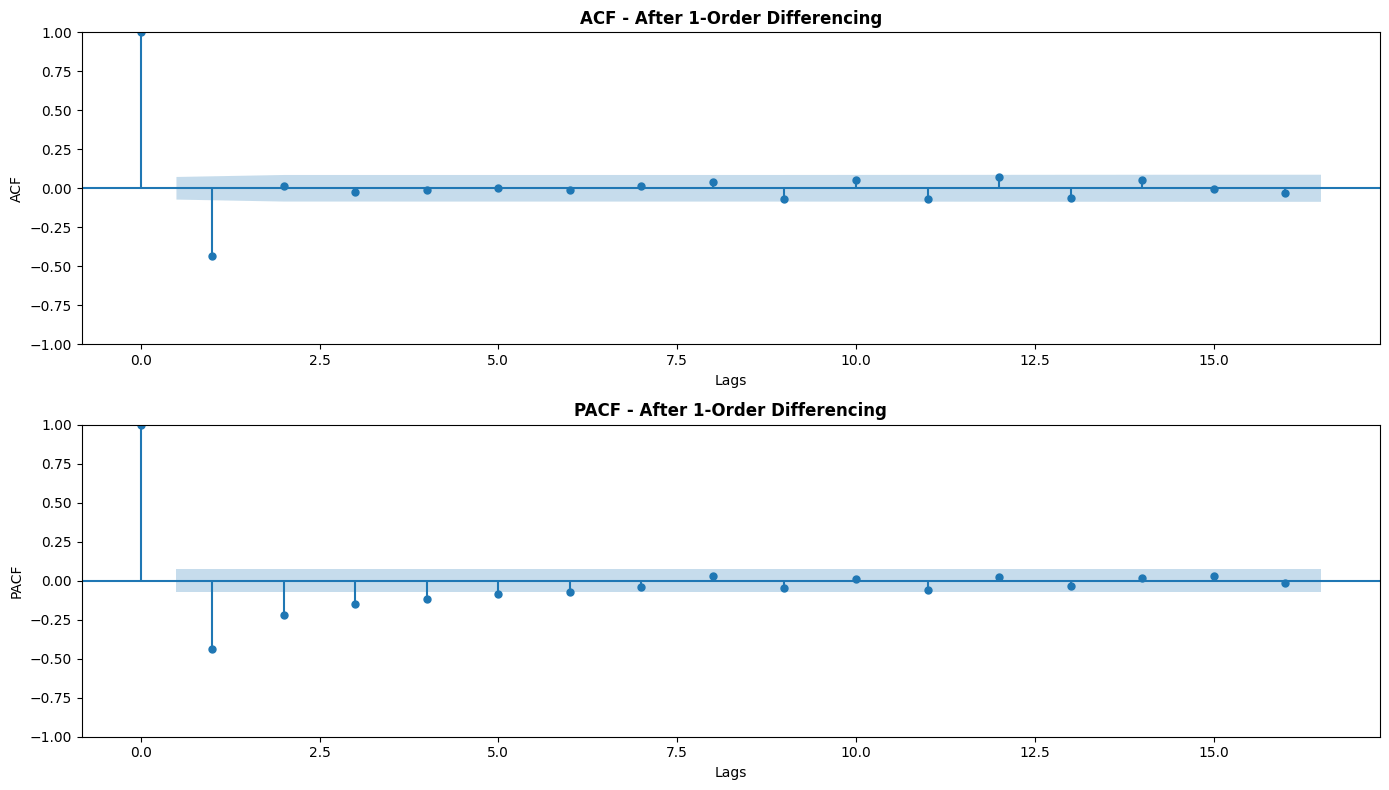

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(timeseries, lags=20, title=""):
    """
    Plot ACF and PACF to identify AR/MA/ARIMA patterns

    Interpretation:
    - ACF decays exponentially → AR process
    - PACF cuts off after lag p → AR(p)
    - ACF cuts off after lag q → MA(q)
    - PACF decays exponentially → MA process
    - Both decay → ARMA process
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    plot_acf(timeseries, lags=lags, ax=axes[0])
    axes[0].set_title(f'ACF - {title}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Lags')
    axes[0].set_ylabel('ACF')

    plot_pacf(timeseries, lags=lags, ax=axes[1], method='ywm')
    axes[1].set_title(f'PACF - {title}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Lags')
    axes[1].set_ylabel('PACF')

    plt.tight_layout()
    plt.show()

    return fig

# Plot ACF/PACF for original series
print("\n" + "="*70)
print("ACF/PACF INTERPRETATION GUIDE")
print("="*70)
print("""
AR(p): PACF cuts off at lag p, ACF decays exponentially
MA(q): ACF cuts off at lag q, PACF decays exponentially
ARMA: Both ACF and PACF decay exponentially

Rule of thumb:
- Look for the first lag where ACF/PACF crosses the confidence band
- Count that lag number → that's your p or q
""")

#plot_acf_pacf(df['revenue'], lags=20, title="Original Series")

plot_acf_pacf(revenue_diff, lags=16, title=f"After {d}-Order Differencing")

In [ ]:
# note: since ACF cuts off at lag = 1 and becomes insignificant and PACF gradually decays, this is more likely a MA(1) model

In [ ]:
print("\n" + "="*70)
print("MANUAL MODEL SELECTION (Based on ACF/PACF)")
print("="*70)
print("""
Based on the ACF/PACF plots above, determine:

1. Does PACF have significant spikes? If yes → AR process
   - Count first significant spike → that's p

2. Does ACF have significant spikes? If yes → MA process
   - Count first significant spike → that's q

3. If both have spikes → ARMA(p,q)

Enter your observations below:
""")

# You can manually inspect the plots and enter values
# For now, we'll create candidate models based on visual inspection

p_manual = int(input("Enter p (AR order, or 0 if not AR): ") or "0")
q_manual = int(input("Enter q (MA order, or 0 if not MA): ") or "0")

print(f"\n✓ Your suggested model: ARIMA({p_manual}, {d}, {q_manual})")


MANUAL MODEL SELECTION (Based on ACF/PACF)

Based on the ACF/PACF plots above, determine:

1. Does PACF have significant spikes? If yes → AR process
   - Count first significant spike → that's p

2. Does ACF have significant spikes? If yes → MA process
   - Count first significant spike → that's q

3. If both have spikes → ARMA(p,q)

Enter your observations below:

Enter p (AR order, or 0 if not AR): 0
Enter q (MA order, or 0 if not MA): 1

✓ Your suggested model: ARIMA(0, 1, 1)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Train-test split
train_size = int(len(df) * 0.8)
train_data = df['revenue'].iloc[:train_size]
test_data = df['revenue'].iloc[train_size:]

print(f"\nTrain set: {len(train_data)} observations")
print(f"Test set: {len(test_data)} observations")

# Define candidate models
candidates = [
    (p_manual, d, q_manual),  # Your manual suggestion
    (1, 0, 0),  # AR(1)
    (0, 0, 1),  # MA(1)
    (1, 1, 0),  # ARIMA(1,1,0)
    (0, 1, 1),  # ARIMA(0,1,1)
    (1, 1, 1),  # ARIMA(1,1,1) - classic
    (2, 1, 0),  # ARIMA(2,1,0)
    (0, 1, 2),  # ARIMA(0,1,2)
    (2, 1, 1),  # ARIMA(2,1,1)
    (1, 1, 2),  # ARIMA(1,1,2)
]

# Remove duplicates
candidates = list(set(candidates))

print(f"\nTesting {len(candidates)} candidate models...\n")


Train set: 584 observations
Test set: 147 observations

Testing 9 candidate models...



In [ ]:
results = []

for order in candidates:
    try:
        # Fit model
        model = ARIMA(train_data, order=order)
        model_fit = model.fit()

        # Get AIC and BIC from training data
        aic = model_fit.aic
        bic = model_fit.bic

        # Make predictions on test set
        predictions = model_fit.forecast(steps=len(test_data))

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(test_data, predictions))
        mae = mean_absolute_error(test_data, predictions)
        mape = np.mean(np.abs((test_data - predictions) / test_data)) * 100

        # R² (R-squared)
        r2 = r2_score(test_data, predictions)

        # Adjusted R² (for fair comparison across different p, d, q)
        n = len(test_data)
        k = order[0] + order[2]  # number of parameters (p + q)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1) if (n - k - 1) > 0 else r2

        results.append({
            'ARIMA Order': f"ARIMA{order}",
            'p': order[0],
            'd': order[1],
            'q': order[2],
            'AIC': aic,
            'BIC': bic,
            'R²': r2,
            'Adj. R²': adj_r2,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'Model': model_fit
        })

        print(f"✓ {order} - AIC: {aic:,.0f}, BIC: {bic:,.0f}, R²: {r2:.4f}")

    except Exception as e:
        print(f"✗ {order} - Failed: {str(e)[:50]}")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.drop('Model', axis=1)  # Remove model object for display

print(f"\n{'='*70}")
print("MODEL COMPARISON RESULTS")
print(f"{'='*70}")
print(results_df.to_string(index=False))

✓ (2, 1, 1) - AIC: 9,955, BIC: 9,973, R²: -0.0100
✓ (1, 1, 0) - AIC: 10,023, BIC: 10,032, R²: -0.2813
✓ (2, 1, 0) - AIC: 9,986, BIC: 9,999, R²: -0.0712
✓ (1, 1, 2) - AIC: 9,953, BIC: 9,971, R²: -0.0080
✓ (1, 0, 0) - AIC: 10,095, BIC: 10,108, R²: -0.3453
✓ (0, 1, 2) - AIC: 9,953, BIC: 9,966, R²: -0.0087
✓ (0, 0, 1) - AIC: 10,318, BIC: 10,331, R²: -0.3450
✓ (1, 1, 1) - AIC: 9,953, BIC: 9,967, R²: -0.0088
✓ (0, 1, 1) - AIC: 9,952, BIC: 9,960, R²: -0.0072

MODEL COMPARISON RESULTS
   ARIMA Order  p  d  q          AIC          BIC        R²   Adj. R²        RMSE         MAE      MAPE
ARIMA(2, 1, 1)  2  1  1  9955.308448  9972.781197 -0.010021 -0.031211 1417.994215 1141.344226 52.838957
ARIMA(1, 1, 0)  1  1  0 10022.847664 10031.584038 -0.281277 -0.290113 1597.094743 1321.723443 46.042623
ARIMA(2, 1, 0)  2  1  0  9986.013278  9999.117840 -0.071166 -0.086043 1460.284884 1190.325355 47.375156
ARIMA(1, 1, 2)  1  1  2  9953.485886  9970.958635 -0.008045 -0.029192 1416.606052 1140.136425 52.57294

In [ ]:
print(f"\n{'='*70}")
print("BEST MODELS BY DIFFERENT CRITERIA")
print(f"{'='*70}")

# Best by AIC (Akaike Information Criterion)
best_aic_idx = results_df['AIC'].idxmin()
best_aic = results_df.loc[best_aic_idx]
print(f"\n1. BEST BY AIC (Lower is Better):")
print(f"   {best_aic['ARIMA Order']}")
print(f"   AIC: {best_aic['AIC']:,.0f}")

# Best by BIC (Bayesian Information Criterion)
best_bic_idx = results_df['BIC'].idxmin()
best_bic = results_df.loc[best_bic_idx]
print(f"\n2. BEST BY BIC (Lower is Better):")
print(f"   {best_bic['ARIMA Order']}")
print(f"   BIC: {best_bic['BIC']:,.0f}")

# Best by R² (Higher is Better)
best_r2_idx = results_df['R²'].idxmax()
best_r2 = results_df.loc[best_r2_idx]
print(f"\n3. BEST BY R² (Higher is Better):")
print(f"   {best_r2['ARIMA Order']}")
print(f"   R²: {best_r2['R²']:.4f}")

# Best by Adjusted R² (accounts for model complexity)
best_adj_r2_idx = results_df['Adj. R²'].idxmax()
best_adj_r2 = results_df.loc[best_adj_r2_idx]
print(f"\n4. BEST BY ADJUSTED R² (Penalizes Complexity):")
print(f"   {best_adj_r2['ARIMA Order']}")
print(f"   Adj. R²: {best_adj_r2['Adj. R²']:.4f}")

# Best by RMSE (Lower is Better)
best_rmse_idx = results_df['RMSE'].idxmin()
best_rmse = results_df.loc[best_rmse_idx]
print(f"\n5. BEST BY RMSE (Lower is Better):")
print(f"   {best_rmse['ARIMA Order']}")
print(f"   RMSE: {best_rmse['RMSE']:,.2f}")

# Best by MAPE (Lower is Better)
best_mape_idx = results_df['MAPE'].idxmin()
best_mape = results_df.loc[best_mape_idx]
print(f"\n6. BEST BY MAPE (Lower is Better):")
print(f"   {best_mape['ARIMA Order']}")
print(f"   MAPE: {best_mape['MAPE']:.2f}%")


BEST MODELS BY DIFFERENT CRITERIA

1. BEST BY AIC (Lower is Better):
   ARIMA(0, 1, 1)
   AIC: 9,952

2. BEST BY BIC (Lower is Better):
   ARIMA(0, 1, 1)
   BIC: 9,960

3. BEST BY R² (Higher is Better):
   ARIMA(0, 1, 1)
   R²: -0.0072

4. BEST BY ADJUSTED R² (Penalizes Complexity):
   ARIMA(0, 1, 1)
   Adj. R²: -0.0141

5. BEST BY RMSE (Lower is Better):
   ARIMA(0, 1, 1)
   RMSE: 1,416.01

6. BEST BY MAPE (Lower is Better):
   ARIMA(1, 1, 0)
   MAPE: 46.04%


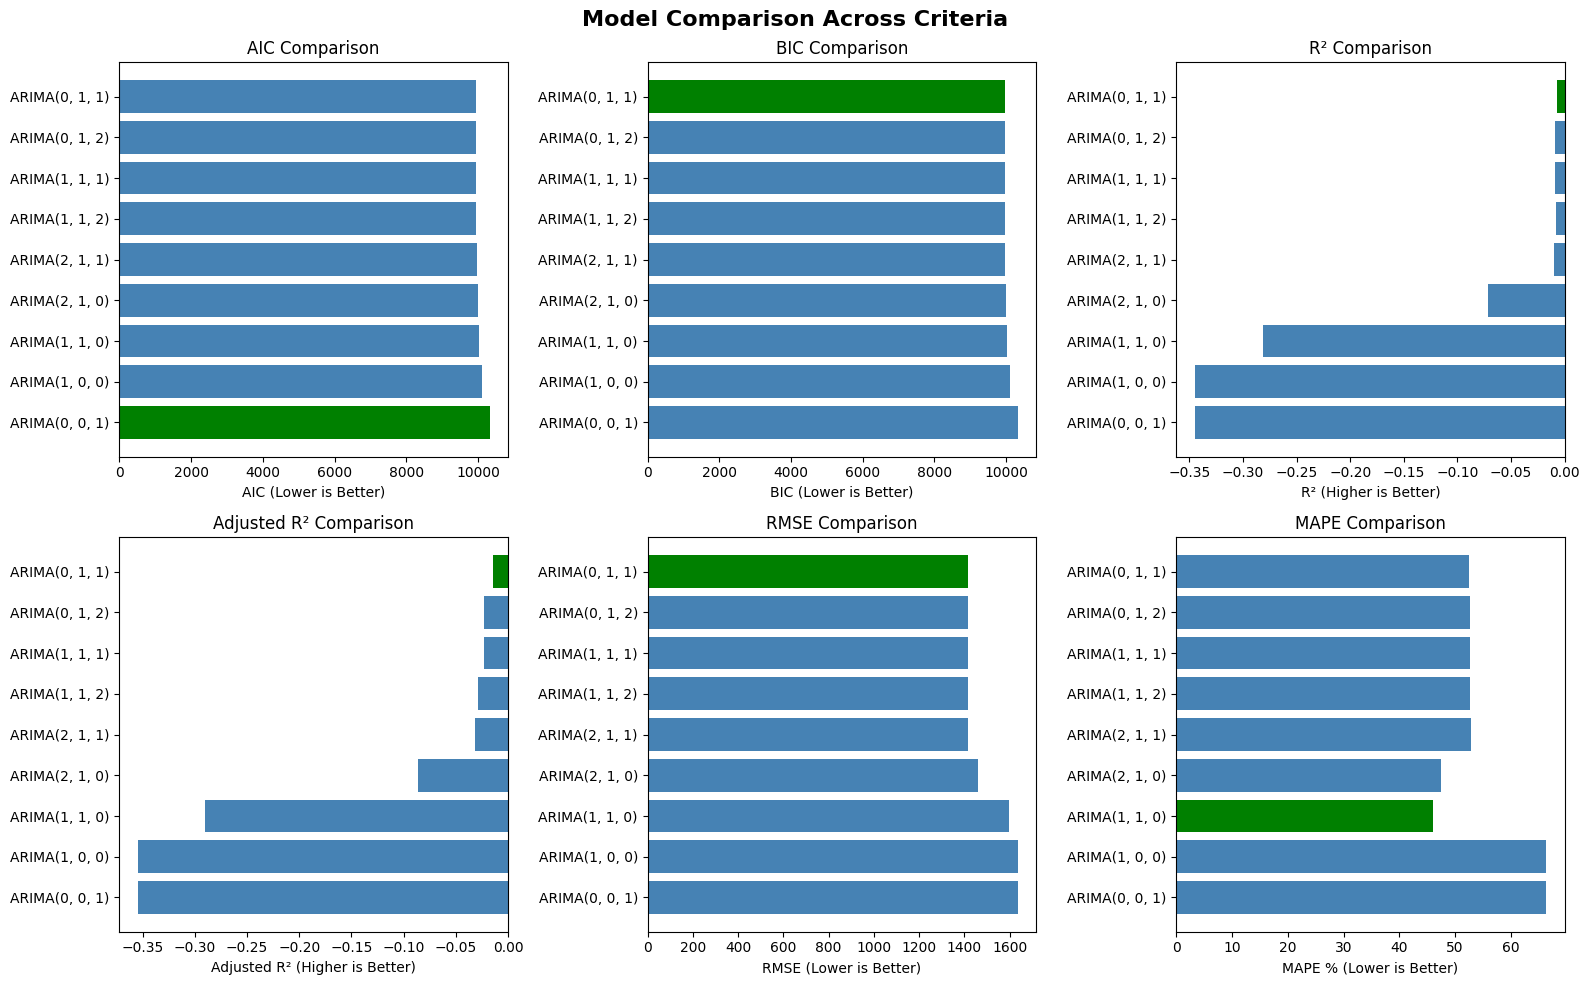


✓ Green bar = Best model for that criterion


In [ ]:
# Prepare data for visualization
results_display = results_df.copy()
results_display = results_display.sort_values('AIC').reset_index(drop=True)

# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Comparison Across Criteria', fontsize=16, fontweight='bold')

# AIC
ax = axes[0, 0]
colors_aic = ['green' if i == best_aic_idx else 'steelblue' for i in results_display.index]
ax.barh(results_display['ARIMA Order'], results_display['AIC'], color=colors_aic)
ax.set_xlabel('AIC (Lower is Better)')
ax.set_title('AIC Comparison')
ax.invert_yaxis()

# BIC
ax = axes[0, 1]
colors_bic = ['green' if results_display.loc[i, 'ARIMA Order'] == best_bic['ARIMA Order'] else 'steelblue' for i in results_display.index]
ax.barh(results_display['ARIMA Order'], results_display['BIC'], color=colors_bic)
ax.set_xlabel('BIC (Lower is Better)')
ax.set_title('BIC Comparison')
ax.invert_yaxis()

# R²
ax = axes[0, 2]
colors_r2 = ['green' if results_display.loc[i, 'ARIMA Order'] == best_r2['ARIMA Order'] else 'steelblue' for i in results_display.index]
ax.barh(results_display['ARIMA Order'], results_display['R²'], color=colors_r2)
ax.set_xlabel('R² (Higher is Better)')
ax.set_title('R² Comparison')
ax.invert_yaxis()

# Adjusted R²
ax = axes[1, 0]
colors_adj_r2 = ['green' if results_display.loc[i, 'ARIMA Order'] == best_adj_r2['ARIMA Order'] else 'steelblue' for i in results_display.index]
ax.barh(results_display['ARIMA Order'], results_display['Adj. R²'], color=colors_adj_r2)
ax.set_xlabel('Adjusted R² (Higher is Better)')
ax.set_title('Adjusted R² Comparison')
ax.invert_yaxis()

# RMSE
ax = axes[1, 1]
colors_rmse = ['green' if results_display.loc[i, 'ARIMA Order'] == best_rmse['ARIMA Order'] else 'steelblue' for i in results_display.index]
ax.barh(results_display['ARIMA Order'], results_display['RMSE'], color=colors_rmse)
ax.set_xlabel('RMSE (Lower is Better)')
ax.set_title('RMSE Comparison')
ax.invert_yaxis()

# MAPE
ax = axes[1, 2]
colors_mape = ['green' if results_display.loc[i, 'ARIMA Order'] == best_mape['ARIMA Order'] else 'steelblue' for i in results_display.index]
ax.barh(results_display['ARIMA Order'], results_display['MAPE'], color=colors_mape)
ax.set_xlabel('MAPE % (Lower is Better)')
ax.set_title('MAPE Comparison')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✓ Green bar = Best model for that criterion")

In [ ]:
print(f"\n{'='*70}")
print("RECOMMENDATION")
print(f"{'='*70}")
print("""
WHICH CRITERION TO USE?

1. AIC: Preferred for forecast accuracy (balances fit & complexity)
2. BIC: Preferred when you want simpler models (stronger penalty)
3. R²: Raw goodness-of-fit (can overfit with more parameters)
4. Adjusted R²: Better - penalizes complexity
5. RMSE/MAPE: Good for understanding forecast error magnitude

>>> RECOMMENDATION: Use AIC for ARIMA model selection <<<
   (It's the standard in time series forecasting)
""")

# Use best AIC model
selected_order = tuple(map(int, best_aic['ARIMA Order'].replace('ARIMA(', '').replace(')', '').split(', ')))
print(f"\nSelected Model: ARIMA{selected_order}")
print(f"AIC: {best_aic['AIC']:,.0f}")
print(f"R²: {best_aic['R²']:.4f}")
print(f"RMSE: {best_aic['RMSE']:,.2f}")


RECOMMENDATION

WHICH CRITERION TO USE?

1. AIC: Preferred for forecast accuracy (balances fit & complexity)
2. BIC: Preferred when you want simpler models (stronger penalty)
3. R²: Raw goodness-of-fit (can overfit with more parameters)
4. Adjusted R²: Better - penalizes complexity
5. RMSE/MAPE: Good for understanding forecast error magnitude

>>> RECOMMENDATION: Use AIC for ARIMA model selection <<<
   (It's the standard in time series forecasting)


Selected Model: ARIMA(0, 1, 1)
AIC: 9,952
R²: -0.0072
RMSE: 1,416.01


In [ ]:
print(df)

                                     date  revenue  year  \
1970-01-01 00:00:00.000000000  2011-01-01      985  2011   
1970-01-01 00:00:00.000000001  2012-01-04     2368  2012   
1970-01-01 00:00:00.000000002  2012-01-05     3272  2012   
1970-01-01 00:00:00.000000003  2012-01-06     4098  2012   
1970-01-01 00:00:00.000000004  2012-01-07     4521  2012   
...                                   ...      ...   ...   
1970-01-01 00:00:00.000000726  2011-12-28     2302  2011   
1970-01-01 00:00:00.000000727  2011-12-29     2423  2011   
1970-01-01 00:00:00.000000728  2011-12-30     2999  2011   
1970-01-01 00:00:00.000000729  2011-12-17     2739  2011   
1970-01-01 00:00:00.000000730  2012-12-31     2729  2012   

                                                      month  quarter  \
1970-01-01 00:00:00.000000000 1970-01-01 00:00:00.000000001        1   
1970-01-01 00:00:00.000000001 1970-01-01 00:00:00.000000001        1   
1970-01-01 00:00:00.000000002 1970-01-01 00:00:00.000000001    

In [ ]:
# Fit on all available data (not just train set)
final_model = ARIMA(df['revenue'], order=selected_order)
final_fit = final_model.fit()

# Print model summary
print("\n" + "="*70)
print("FINAL MODEL SUMMARY")
print("="*70)
print(final_fit.summary())

# Generate 12-month forecast
forecast = final_fit.forecast(steps=12)
forecast_ci = final_fit.get_forecast(steps=12).conf_int()

# Create forecast dataframe
# last_date = df.index.max()
# df.index = pd.to_datetime(df.index)
# last_date = df.index.max()
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

last_date = df.index.max()
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=12,
    freq='MS'
)
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=12, freq='MS')

forecast_df = pd.DataFrame({
    'month': future_dates,
    'forecast': forecast.values,
    'lower_ci': forecast_ci.iloc[:, 0].values,
    'upper_ci': forecast_ci.iloc[:, 1].values
})

print(f"\n{'='*70}")
print("12-MONTH FORECAST")
print(f"{'='*70}")
print(forecast_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)



FINAL MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                  731
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -6208.769
Date:                Sun, 17 May 2026   AIC                          12421.539
Time:                        17:20:53   BIC                          12430.725
Sample:                    01-01-1970   HQIC                         12425.083
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6306      0.024    -25.913      0.000      -0.678      -0.583
sigma2      1.427e+06   4.71e+04     30.306      0.000    1.33e+06    1.52e+06
Ljung-Box (L1) (Q):            

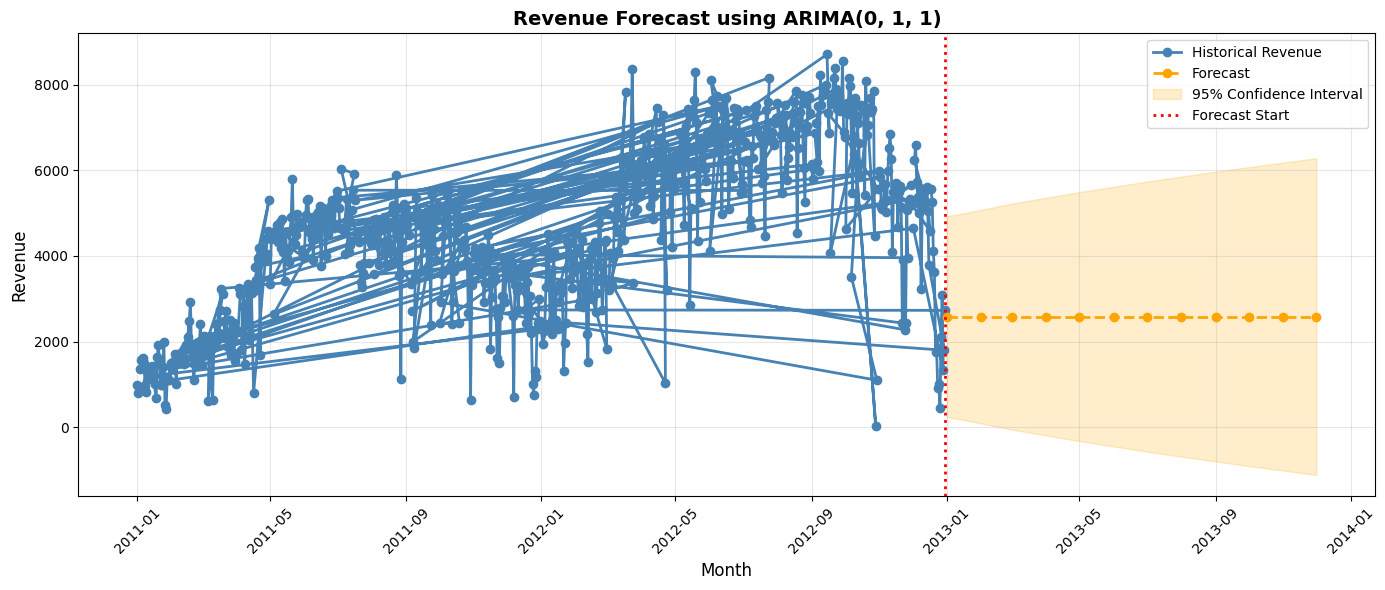

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historical data
ax.plot(df.index, df['revenue'], label='Historical Revenue', marker='o', linewidth=2, color='steelblue')

# Forecast
ax.plot(forecast_df['month'], forecast_df['forecast'], label='Forecast', marker='o', linewidth=2, color='orange', linestyle='--')

# Confidence interval
ax.fill_between(
    forecast_df['month'],
    forecast_df['lower_ci'],
    forecast_df['upper_ci'],
    alpha=0.2,
    color='orange',
    label='95% Confidence Interval'
)

ax.axvline(x=df.index.max(), color='red', linestyle=':', linewidth=2, label='Forecast Start')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue', fontsize=12)
ax.set_title(f'Revenue Forecast using ARIMA{selected_order}', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

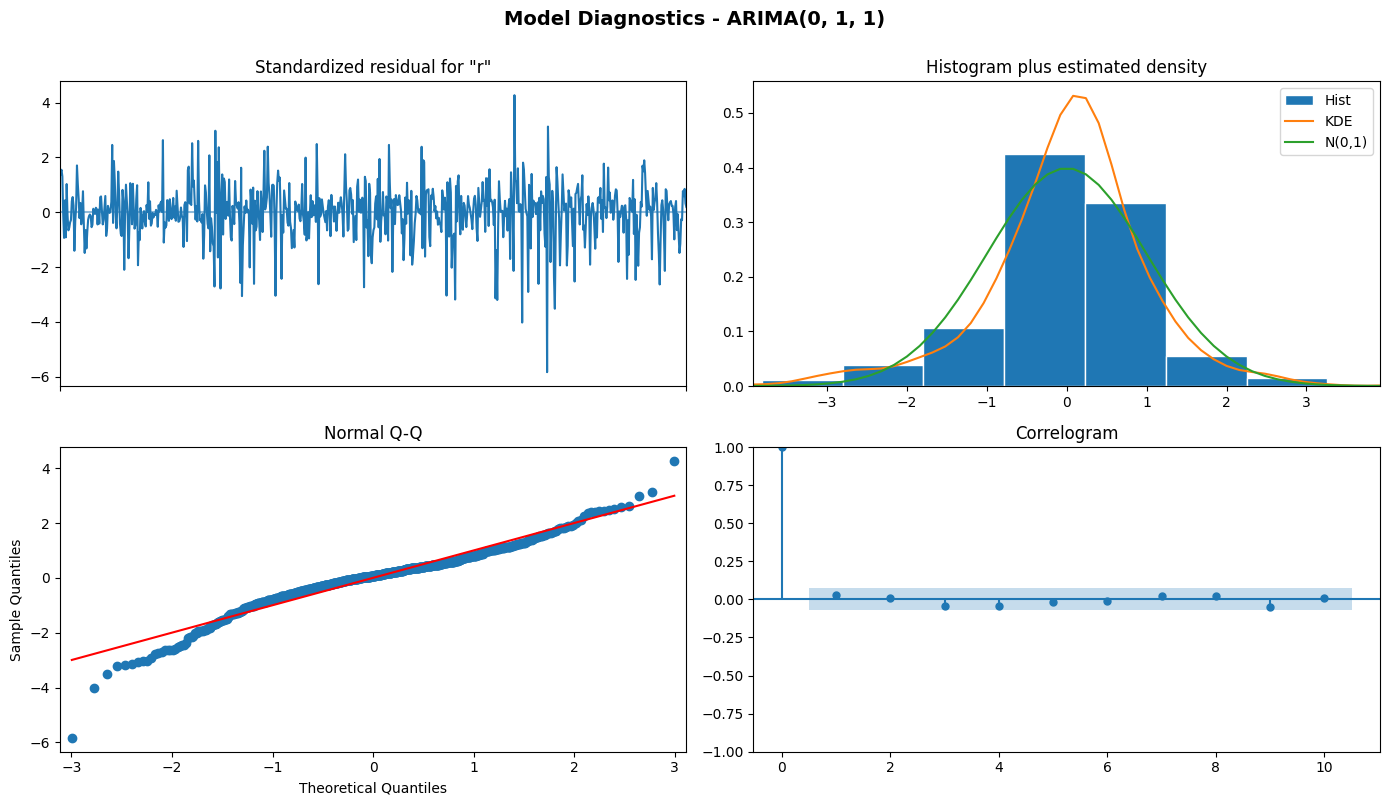


Diagnostic Plots Explanation:

1. Standardized Residuals: Should look like white noise (no patterns)
2. Histogram + KDE: Should follow normal distribution
3. Normal Q-Q Plot: Points should follow the red line (normal distribution)
4. Correlogram (ACF): Residuals should have no significant autocorrelation

If any look problematic, try different (p,d,q) values.



In [ ]:
# Plot diagnostics
fig = final_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Model Diagnostics - ARIMA{selected_order}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("""
Diagnostic Plots Explanation:

1. Standardized Residuals: Should look like white noise (no patterns)
2. Histogram + KDE: Should follow normal distribution
3. Normal Q-Q Plot: Points should follow the red line (normal distribution)
4. Correlogram (ACF): Residuals should have no significant autocorrelation

If any look problematic, try different (p,d,q) values.
""")